<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/13_Temporal_Convolutional_Network_(TCN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

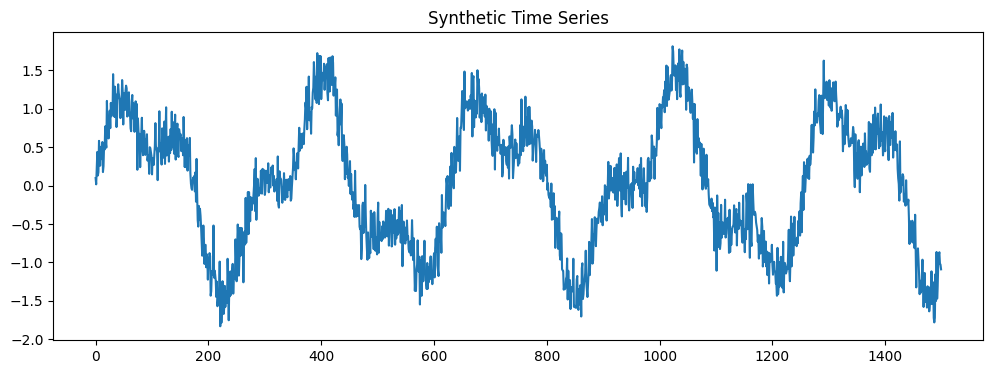

In [2]:
time = np.arange(0,1500)

series = (
    np.sin(0.02*time)
    +0.5*np.sin(0.05*time)
    +0.2*np.random.randn(len(time))
)

plt.figure(figsize=(12,4))
plt.plot(series)
plt.title("Synthetic Time Series")
plt.show()

In [3]:
window_size = 30

X=[]
Y=[]

for i in range(len(series)-window_size):
    X.append(series[i:i+window_size])
    Y.append(series[i+window_size])

X=np.array(X)
Y=np.array(Y)

print(X.shape)
print(Y.shape)

(1470, 30)
(1470,)


In [4]:
split=int(len(X)*0.8)

X_train=X[:split]
Y_train=Y[:split]

X_test=X[split:]
Y_test=Y[split:]

In [5]:
class TimeSeriesDataset(Dataset):

    def __init__(self,X,Y):

        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        return self.X[idx],self.Y[idx]

In [6]:
train_loader=DataLoader(
    TimeSeriesDataset(X_train,Y_train),
    batch_size=64,
    shuffle=True
)

test_loader=DataLoader(
    TimeSeriesDataset(X_test,Y_test),
    batch_size=64,
    shuffle=False
)

In [7]:
class Chomp1d(nn.Module):

    def __init__(self,chomp_size):
        super().__init__()
        self.chomp_size=chomp_size

    def forward(self,x):

        return x[:,:,:-self.chomp_size]

In [8]:
class TemporalBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 dilation):

        super().__init__()

        padding=(kernel_size-1)*dilation

        self.conv1=nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.chomp1=Chomp1d(padding)

        self.relu1=nn.ReLU()

        self.conv2=nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.chomp2=Chomp1d(padding)

        self.relu2=nn.ReLU()

        self.downsample=None

        if in_channels!=out_channels:
            self.downsample=nn.Conv1d(
                in_channels,
                out_channels,
                1
            )

        self.final_relu=nn.ReLU()

    def forward(self,x):

        out=self.conv1(x)
        out=self.chomp1(out)
        out=self.relu1(out)

        out=self.conv2(out)
        out=self.chomp2(out)
        out=self.relu2(out)

        res=x

        if self.downsample is not None:
            res=self.downsample(x)

        return self.final_relu(out+res)

In [9]:
class TCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network=nn.Sequential(

            TemporalBlock(1,16,3,1),

            TemporalBlock(16,32,3,2),

            TemporalBlock(32,64,3,4),

            TemporalBlock(64,64,3,8),

            TemporalBlock(64,64,3,16)

        )

        self.fc=nn.Linear(64,1)

    def forward(self,x):

        x=x.unsqueeze(1)

        out=self.network(x)

        out=out[:,:,-1]

        out=self.fc(out)

        return out.squeeze()

In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=TCN().to(device)

criterion=nn.MSELoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
epochs=5

losses=[]

for epoch in range(epochs):

    model.train()

    running_loss=0

    for X_batch,Y_batch in train_loader:

        X_batch=X_batch.to(device)
        Y_batch=Y_batch.to(device)

        optimizer.zero_grad()

        pred=model(X_batch)

        loss=criterion(pred,Y_batch)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

    epoch_loss=running_loss/len(train_loader)

    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} Loss={epoch_loss:.6f}")

Epoch 1/5 Loss=0.045719
Epoch 2/5 Loss=0.044025
Epoch 3/5 Loss=0.044694
Epoch 4/5 Loss=0.048893
Epoch 5/5 Loss=0.042962


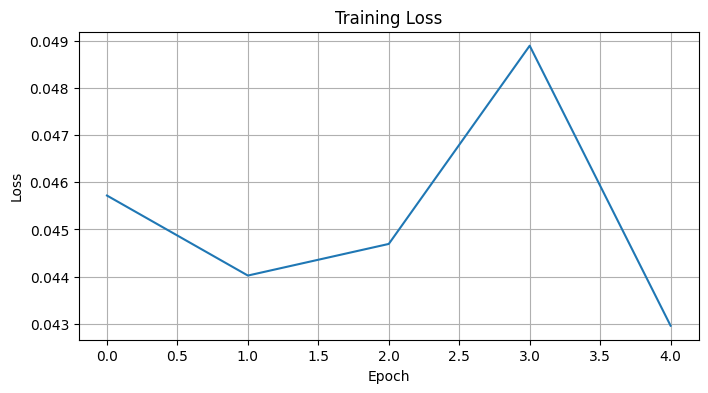

In [13]:
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid()

plt.show()

In [14]:
model.eval()

predictions=[]

actual=[]

with torch.no_grad():

    for X_batch,Y_batch in test_loader:

        X_batch=X_batch.to(device)

        pred=model(X_batch)

        predictions.extend(pred.cpu().numpy())

        actual.extend(Y_batch.numpy())

In [15]:
predictions=np.array(predictions)
actual=np.array(actual)

mse=np.mean((predictions-actual)**2)

rmse=np.sqrt(mse)

mae=np.mean(np.abs(predictions-actual))

print("MSE :",mse)
print("RMSE:",rmse)
print("MAE :",mae)

MSE : 0.05013377
RMSE: 0.22390571
MAE : 0.18340759


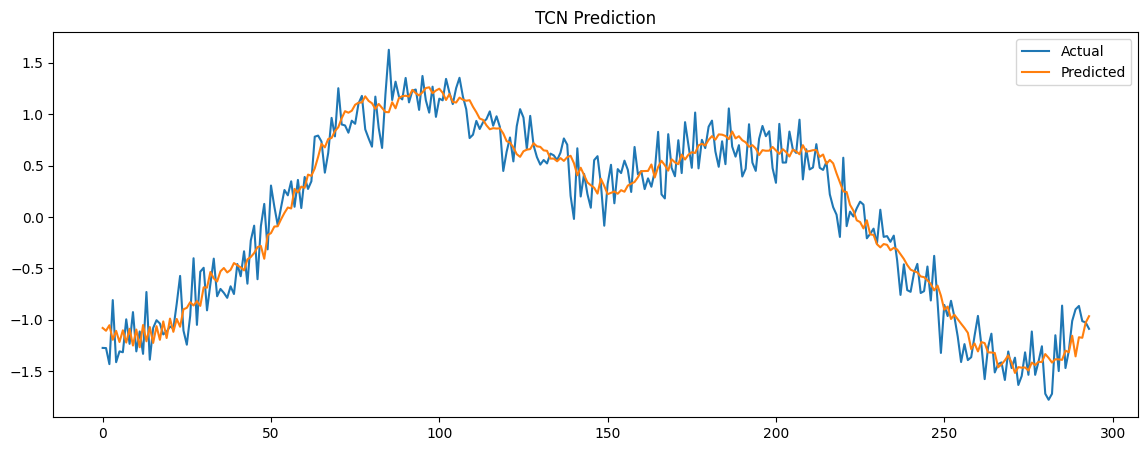

In [16]:
plt.figure(figsize=(14,5))

plt.plot(actual,label="Actual")

plt.plot(predictions,label="Predicted")

plt.legend()

plt.title("TCN Prediction")

plt.show()